# Heart Disease Risk Classifier — Phase 4: Evaluation & Storytelling
Cleveland Heart Disease Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score, f1_score,
                             precision_score, recall_score,
                             accuracy_score, roc_auc_score,
                             classification_report)

SEED = 42

In [2]:
# Load, clean and split data

 
COL_NAMES = ["age", "sex", "cp", "trestbps", "chol", "fbs",
             "restecg", "thalach", "exang", "oldpeak",
             "slope", "ca", "thal", "target"]
 
try:
    df = pd.read_csv("heart.csv")
    if df.shape[1] != 14:
        raise ValueError
except Exception:
    df = pd.read_csv("heart.csv", header=None, names=COL_NAMES)
 
df.replace("?", np.nan, inplace=True)
df["ca"]   = pd.to_numeric(df["ca"],   errors="coerce")
df["thal"] = pd.to_numeric(df["thal"], errors="coerce")
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
if df["target"].max() > 1:
    df["target"] = (df["target"] > 0).astype(int)
 
X = df.drop(columns=["target"])
y = df["target"]
 
CATEGORICAL = ["cp", "restecg", "slope", "thal"]
NUMERICAL   = ["age", "trestbps", "chol", "thalach",
               "oldpeak", "ca", "sex", "fbs", "exang"]
 
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler",  StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("encoder", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))])
preprocessor = ColumnTransformer([("num", num_pipe, NUMERICAL),
                                   ("cat", cat_pipe, CATEGORICAL)])
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
 
models = {
    "Logistic Regression": Pipeline([("pre", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))]),
    "KNN":                  Pipeline([("pre", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=7))]),
    "Decision Tree":        Pipeline([("pre", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=4, random_state=SEED))]),
    "Random Forest":        Pipeline([("pre", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=SEED))]),
    "SVM":                  Pipeline([("pre", preprocessor),
        ("model", SVC(kernel="rbf", probability=True, random_state=SEED))]),
}

In [5]:
# Fitting all models

for pipe in models.values():
    pipe.fit(X_train, y_train)
 
print("All models trained.\n")

All models trained.



c:\Users\Tammy\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


#  CONFUSION MATRICES — ALL 5 MODELS

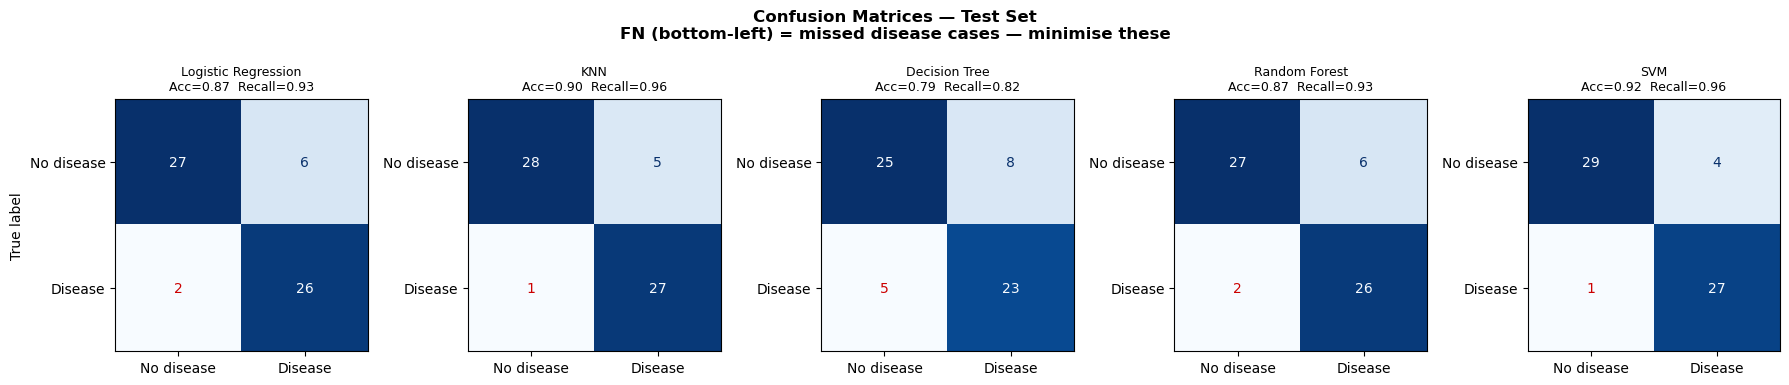

False Negatives (missed disease) per model:
Model                    FN    Recall  (lower FN = better for clinical use)
--------------------------------------------------
  Logistic Regression     2     0.9286
  KNN                     1     0.9643
  Decision Tree           5     0.8214
  Random Forest           2     0.9286
  SVM                     1     0.9643


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Confusion Matrices — Test Set\n"
             "FN (bottom-left) = missed disease cases — minimise these",
             fontweight="bold", fontsize=12)
 
for ax, (name, pipe) in zip(axes, models.items()):
    y_pred = pipe.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=["No disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    ax.set_title(f"{name}\nAcc={acc:.2f}  Recall={rec:.2f}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("" if name != "Logistic Regression" else "True label")
    # Highlight FN cell in red
    fn_val = cm[1, 0]
    ax.texts[2].set_color("white" if fn_val > cm.max() / 2 else "#cc0000")
 
plt.tight_layout()
plt.savefig("phase4_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Print FN count for each model
print("False Negatives (missed disease) per model:")
print(f"{'Model':<22} {'FN':>4}  {'Recall':>8}  (lower FN = better for clinical use)")
print("-" * 50)
for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    fn     = cm[1, 0]
    rec    = recall_score(y_test, y_pred)
    print(f"  {name:<20} {fn:>4}     {rec:.4f}")

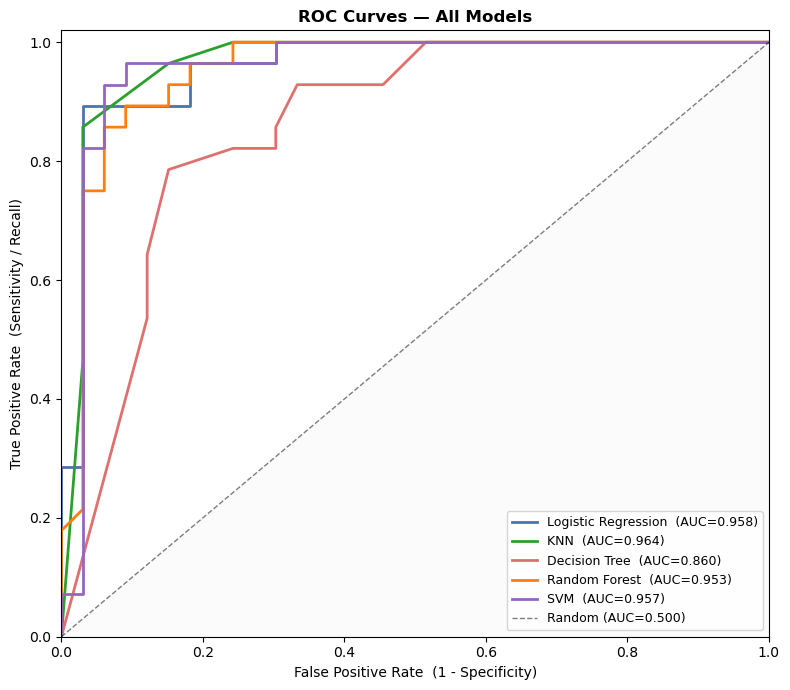


Best AUC-ROC: KNN


In [9]:
# ROC CURVES — ALL MODELS ON ONE CHART

COLORS = ["#4C72B0", "#2ca02c", "#E07070", "#FF7F0E", "#9467BD"]
fig, ax = plt.subplots(figsize=(8, 7))
 
for (name, pipe), color in zip(models.items(), COLORS):
    y_prob        = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _   = roc_curve(y_test, y_prob)
    roc_auc       = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name}  (AUC={roc_auc:.3f})")
 
# Random classifier baseline
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC=0.500)")
ax.fill_between([0, 1], [0, 1], alpha=0.03, color="gray")
 
ax.set_xlabel("False Positive Rate  (1 - Specificity)")
ax.set_ylabel("True Positive Rate  (Sensitivity / Recall)")
ax.set_title("ROC Curves — All Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig("phase4_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
 
best_name = max(models, key=lambda n: roc_auc_score(
    y_test, models[n].predict_proba(X_test)[:, 1]))
print(f"\nBest AUC-ROC: {best_name}")

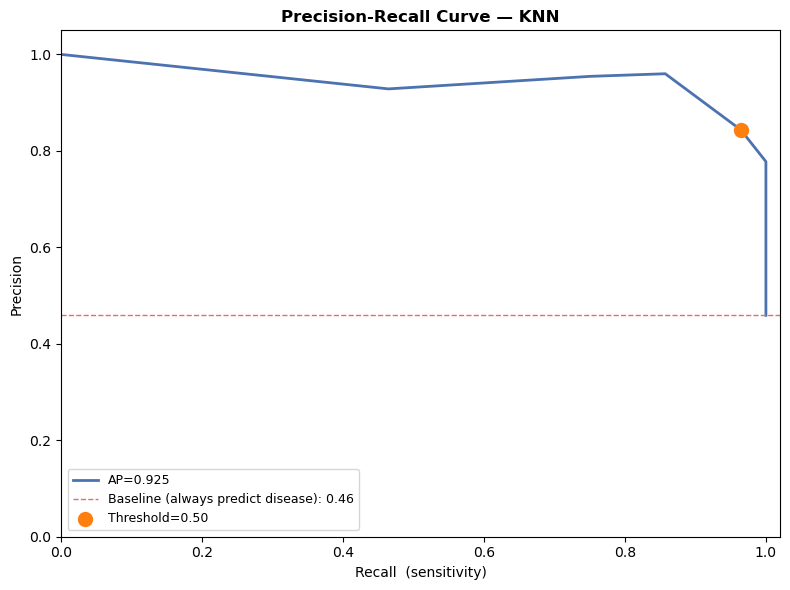

In [10]:
#  PRECISION-RECALL CURVE — BEST MODEL

 
best_pipe = models[best_name]
y_prob    = best_pipe.predict_proba(X_test)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
 
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec, prec, color="#4C72B0", linewidth=2,
        label=f"AP={ap:.3f}")
ax.axhline(y_test.mean(), color="#E07070", linestyle="--",
           linewidth=1, label=f"Baseline (always predict disease): {y_test.mean():.2f}")
 
# Mark default threshold (0.5) point
default_idx  = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(rec[default_idx], prec[default_idx],
           s=100, color="#FF7F0E", zorder=5, label="Threshold=0.50")
 
ax.set_xlabel("Recall  (sensitivity)")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curve — {best_name}", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("phase4_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()


Threshold tuning results:
 Threshold  Precision  Recall    F1  FN  FP
      0.10      0.549   1.000 0.709   0  23
      0.15      0.636   1.000 0.778   0  16
      0.20      0.636   1.000 0.778   0  16
      0.25      0.636   1.000 0.778   0  16
      0.30      0.778   1.000 0.875   0   8
      0.35      0.778   1.000 0.875   0   8
      0.40      0.778   1.000 0.875   0   8
      0.45      0.844   0.964 0.900   1   5
      0.50      0.844   0.964 0.900   1   5
      0.55      0.844   0.964 0.900   1   5
      0.60      0.960   0.857 0.906   4   1
      0.65      0.960   0.857 0.906   4   1
      0.70      0.960   0.857 0.906   4   1
      0.75      0.955   0.750 0.840   7   1
      0.80      0.955   0.750 0.840   7   1
      0.85      0.955   0.750 0.840   7   1
      0.90      0.929   0.464 0.619  15   1

Best F1 at threshold   : 0.60  (F1=0.906  Precision=0.960  Recall=0.857)
Recall ≥ 0.90 achieved : threshold=0.10  (FN=0  Precision=0.549)


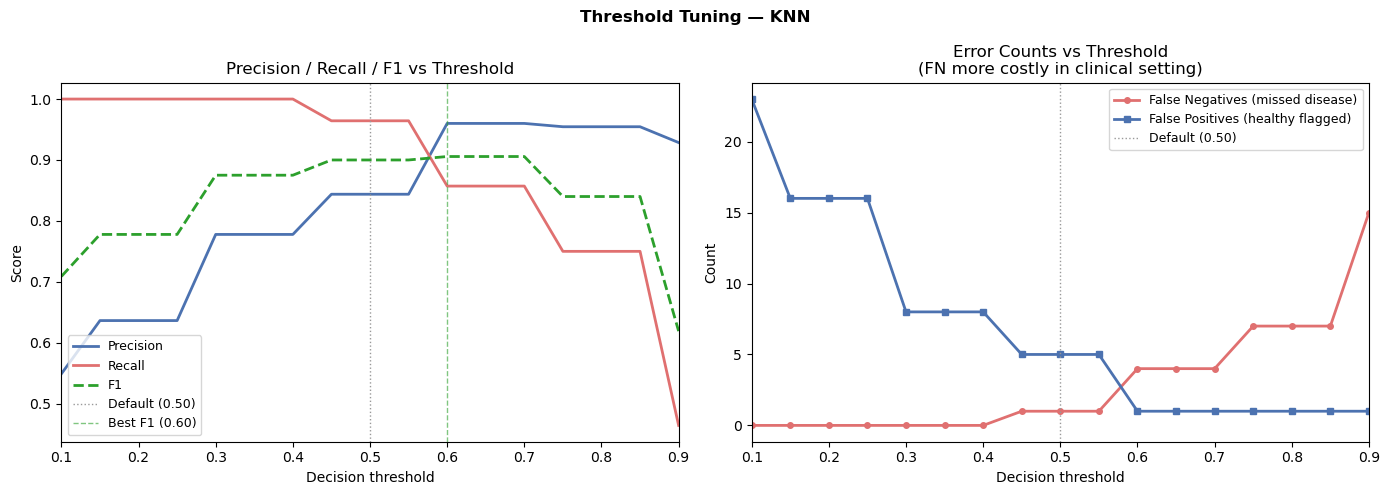

In [11]:
# THRESHOLD TUNING
#    Clinical priority: minimise false negatives (missed disease)
#    → Lower threshold → higher recall, lower precision
#    → Show the tradeoff explicitly
# ════════════════════════════════════════════════════════════════════════════
 
thresh_range = np.arange(0.10, 0.91, 0.05)
thresh_results = []
 
for t in thresh_range:
    y_pred_t = (y_prob >= t).astype(int)
    thresh_results.append({
        "Threshold" : round(t, 2),
        "Precision" : precision_score(y_test, y_pred_t, zero_division=0),
        "Recall"    : recall_score(y_test, y_pred_t, zero_division=0),
        "F1"        : f1_score(y_test, y_pred_t, zero_division=0),
        "FN"        : confusion_matrix(y_test, y_pred_t)[1, 0],
        "FP"        : confusion_matrix(y_test, y_pred_t)[0, 1],
    })
 
thresh_df = pd.DataFrame(thresh_results)
best_f1_idx  = thresh_df["F1"].idxmax()
best_rec_idx = (thresh_df["Recall"] >= 0.90).idxmax()  # first threshold with recall >= 90%
 
print("\nThreshold tuning results:")
print(thresh_df.round(3).to_string(index=False))
print(f"\nBest F1 at threshold   : {thresh_df.loc[best_f1_idx, 'Threshold']:.2f}  "
      f"(F1={thresh_df.loc[best_f1_idx, 'F1']:.3f}  "
      f"Precision={thresh_df.loc[best_f1_idx, 'Precision']:.3f}  "
      f"Recall={thresh_df.loc[best_f1_idx, 'Recall']:.3f})")
print(f"Recall ≥ 0.90 achieved : threshold={thresh_df.loc[best_rec_idx, 'Threshold']:.2f}  "
      f"(FN={thresh_df.loc[best_rec_idx, 'FN']}  "
      f"Precision={thresh_df.loc[best_rec_idx, 'Precision']:.3f})")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Threshold Tuning — {best_name}", fontweight="bold")
 
# Panel 1: Precision, Recall, F1 vs threshold
ax = axes[0]
ax.plot(thresh_df["Threshold"], thresh_df["Precision"],
        color="#4C72B0", linewidth=2, label="Precision")
ax.plot(thresh_df["Threshold"], thresh_df["Recall"],
        color="#E07070", linewidth=2, label="Recall")
ax.plot(thresh_df["Threshold"], thresh_df["F1"],
        color="#2ca02c", linewidth=2, linestyle="--", label="F1")
ax.axvline(0.5, color="#999", linestyle=":", linewidth=1, label="Default (0.50)")
ax.axvline(thresh_df.loc[best_f1_idx, "Threshold"],
           color="#2ca02c", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Best F1 ({thresh_df.loc[best_f1_idx, 'Threshold']:.2f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold")
ax.legend(fontsize=9)
ax.set_xlim(0.1, 0.9)
 
# Panel 2: FN and FP counts vs threshold
ax2 = axes[1]
ax2.plot(thresh_df["Threshold"], thresh_df["FN"],
         color="#E07070", linewidth=2, marker="o", markersize=4, label="False Negatives (missed disease)")
ax2.plot(thresh_df["Threshold"], thresh_df["FP"],
         color="#4C72B0", linewidth=2, marker="s", markersize=4, label="False Positives (healthy flagged)")
ax2.axvline(0.5, color="#999", linestyle=":", linewidth=1, label="Default (0.50)")
ax2.set_xlabel("Decision threshold")
ax2.set_ylabel("Count")
ax2.set_title("Error Counts vs Threshold\n(FN more costly in clinical setting)")
ax2.legend(fontsize=9)
ax2.set_xlim(0.1, 0.9)
 
plt.tight_layout()
plt.savefig("phase4_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
 

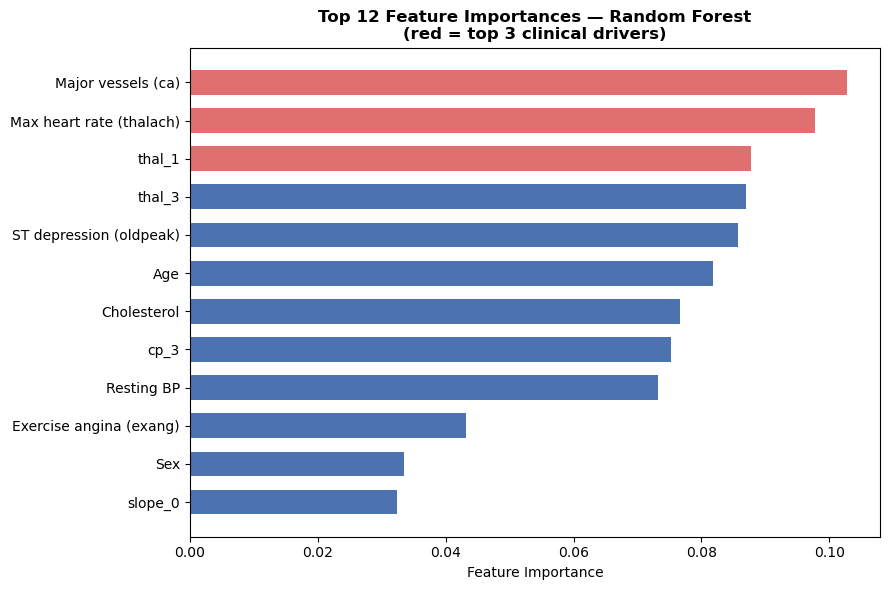


Top 5 features (Random Forest):
Major vessels (ca)          0.1028
Max heart rate (thalach)    0.0978
thal_1                      0.0878
thal_3                      0.0869
ST depression (oldpeak)     0.0858


In [12]:
#  FEATURE IMPORTANCE — RANDOM FOREST

 
rf_pipe  = models["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
 
ohe_feats = (rf_pipe.named_steps["pre"]
               .named_transformers_["cat"]
               .named_steps["encoder"]
               .get_feature_names_out(CATEGORICAL)
               .tolist())
all_features = NUMERICAL + ohe_feats
 
importances = pd.Series(rf_model.feature_importances_, index=all_features)
top12 = importances.nlargest(12).sort_values()
 
FEAT_LABELS = {
    "ca"      : "Major vessels (ca)",
    "thalach" : "Max heart rate (thalach)",
    "oldpeak" : "ST depression (oldpeak)",
    "age"     : "Age",
    "trestbps": "Resting BP",
    "chol"    : "Cholesterol",
    "exang"   : "Exercise angina (exang)",
    "sex"     : "Sex",
    "fbs"     : "Fasting blood sugar",
}
top12.index = [FEAT_LABELS.get(i, i) for i in top12.index]
 
fig, ax = plt.subplots(figsize=(9, 6))
colors  = ["#E07070" if i >= len(top12) - 3 else "#4C72B0"
           for i in range(len(top12))]
ax.barh(top12.index, top12.values, color=colors, height=0.65)
ax.set_xlabel("Feature Importance")
ax.set_title("Top 12 Feature Importances — Random Forest\n"
             "(red = top 3 clinical drivers)", fontweight="bold")
plt.tight_layout()
plt.savefig("phase4_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nTop 5 features (Random Forest):")
print(top12[::-1].head().round(4).to_string())
 
 

In [13]:
# 7. FINAL CLASSIFICATION REPORT + CV SUMMARY

y_pred_best = best_pipe.predict(X_test)
y_prob_best = best_pipe.predict_proba(X_test)[:, 1]
 
print(f"\nFull classification report — {best_name}:")
print(classification_report(y_test, y_pred_best,
                             target_names=["No disease", "Disease"]))
 
# Optimal threshold prediction
opt_thresh  = thresh_df.loc[best_f1_idx, "Threshold"]
y_pred_opt  = (y_prob_best >= opt_thresh).astype(int)
 
print(f"With optimal threshold ({opt_thresh:.2f}):")
print(classification_report(y_test, y_pred_opt,
                             target_names=["No disease", "Disease"]))
 
auc_val   = roc_auc_score(y_test, y_prob_best)
f1_val    = f1_score(y_test, y_pred_best)
rec_val   = recall_score(y_test, y_pred_best)
prec_val  = precision_score(y_test, y_pred_best)
fn_def    = confusion_matrix(y_test, y_pred_best)[1, 0]
fn_opt    = confusion_matrix(y_test, y_pred_opt)[1, 0]
 
print("\n" + "=" * 60)
print("PHASE 4 SUMMARY — USE THIS IN YOUR CV / README")
print("=" * 60)
print(f"""
  Dataset         : Cleveland Heart Disease (303 patients, 13 features)
  Best model      : {best_name}
  AUC-ROC         : {auc_val:.4f}
  F1 Score        : {f1_val:.4f}
  Recall          : {rec_val:.4f}
  Precision       : {prec_val:.4f}
  FN @ thresh=0.5 : {fn_def}  missed disease cases
  FN @ opt thresh : {fn_opt}  missed disease cases (threshold={opt_thresh:.2f})
 
  CV BULLET POINT:
  ─────────────────────────────────────────────────────────
  Built a binary heart disease risk classifier on the
  Cleveland dataset (303 patients), comparing Logistic
  Regression, KNN, Decision Tree, Random Forest, and SVM.
  Best model ({best_name}) achieved AUC-ROC={auc_val:.2f}
  and F1={f1_val:.2f}. Applied threshold tuning to reduce
  false negatives from {fn_def} → {fn_opt}, prioritising
  clinical recall over precision.
  ─────────────────────────────────────────────────────────
""")
 
print("Saved:")
print("  phase4_confusion_matrices.png")
print("  phase4_roc_curves.png")
print("  phase4_pr_curve.png")
print("  phase4_threshold_tuning.png")
print("  phase4_feature_importance.png")
print("\nProject complete. Push to GitHub and update your CV!")


Full classification report — KNN:
              precision    recall  f1-score   support

  No disease       0.97      0.85      0.90        33
     Disease       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61

With optimal threshold (0.60):
              precision    recall  f1-score   support

  No disease       0.89      0.97      0.93        33
     Disease       0.96      0.86      0.91        28

    accuracy                           0.92        61
   macro avg       0.92      0.91      0.92        61
weighted avg       0.92      0.92      0.92        61


PHASE 4 SUMMARY — USE THIS IN YOUR CV / README

  Dataset         : Cleveland Heart Disease (303 patients, 13 features)
  Best model      : KNN
  AUC-ROC         : 0.9643
  F1 Score        : 0.9000
  Recall          : 0.9643
  Precision       : 0.8438
  FN @ thresh=0.5 : 1  miss